load dataset of csv file

transformation

visualization

insight save to the pdf format

# 1. load dataset

In [1]:
import pandas as pd
df = pd.read_csv("D:/SEMESTER 5 pratical/Advanced python programming for data science/data/Chocolate Sales (2).csv")
print(df.head())

     Sales Person    Country              Product        Date      Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04/01/2022   $5,320.00   
1     Van Tuxwell      India        85% Dark Bars  01/08/2022   $7,896.00   
2    Gigi Bohling      India  Peanut Butter Cubes  07/07/2022   $4,501.00   
3    Jan Morforth  Australia  Peanut Butter Cubes  27/04/2022  $12,726.00   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24/02/2022  $13,685.00   

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  


# 2. transforamtion

In [2]:
df.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [4]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [5]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [6]:
# Remove leading/trailing spaces
df['Sales Person'] = df['Sales Person'].str.strip()
df['Country'] = df['Country'].str.strip()
df['Product'] = df['Product'].str.strip()

# Standardize case
df['Country'] = df['Country'].str.title()
df['Product'] = df['Product'].str.title()

In [8]:
# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Create Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

In [9]:
# Country-wise sales
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

# Product-wise sales
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

# Salesperson performance
person_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

# Monthly sales
monthly_sales = df.groupby('Month')['Amount'].sum()

In [14]:
# Remove $ and commas, then convert to float
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\acer\AppData\Local\Temp\ipykernel_17248\2701375146.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)


# 3. Visualization

Bar Chart – Sales by Country

In [11]:
import matplotlib.pyplot as plt

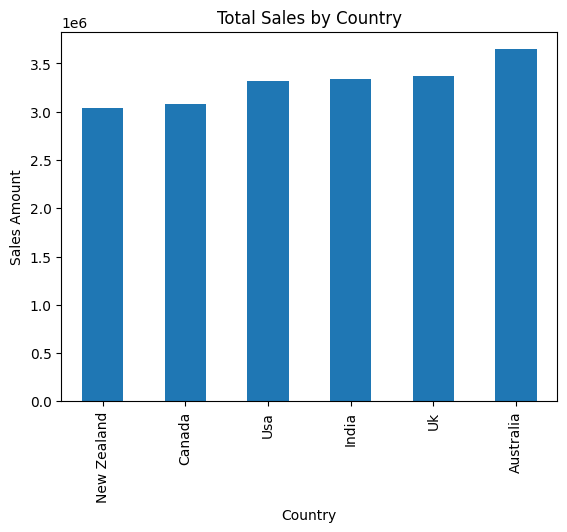

In [15]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values()

plt.figure()
country_sales.plot(kind='bar')
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales Amount")
plt.show()

Bar Chart – Sales by Product

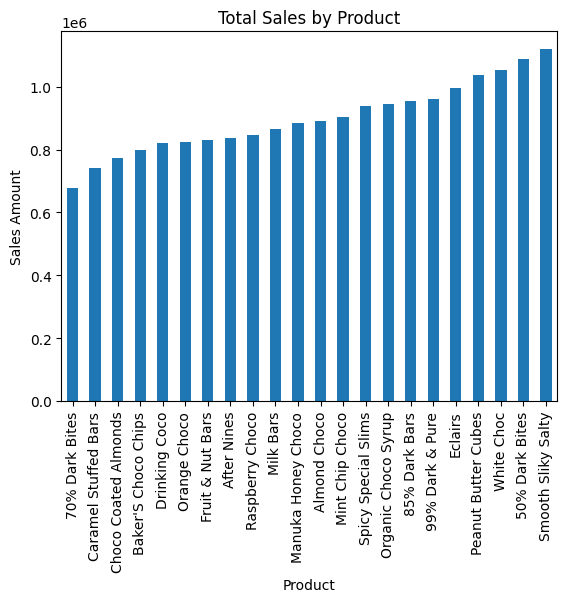

In [16]:
product_sales = df.groupby('Product')['Amount'].sum().sort_values()

plt.figure()
product_sales.plot(kind='bar')
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales Amount")
plt.show()

Line Chart – Monthly Sales Trend

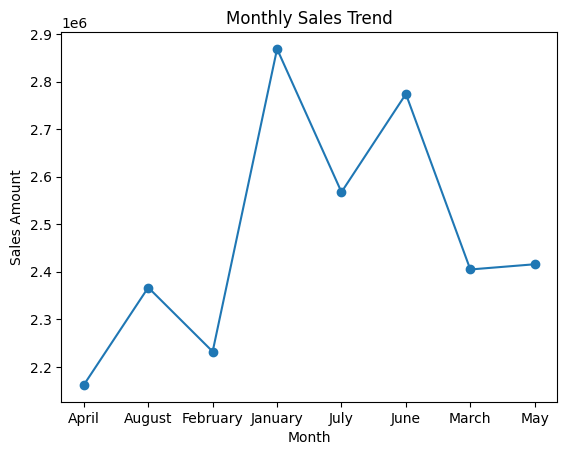

In [17]:
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()

Top 10 Salespersons

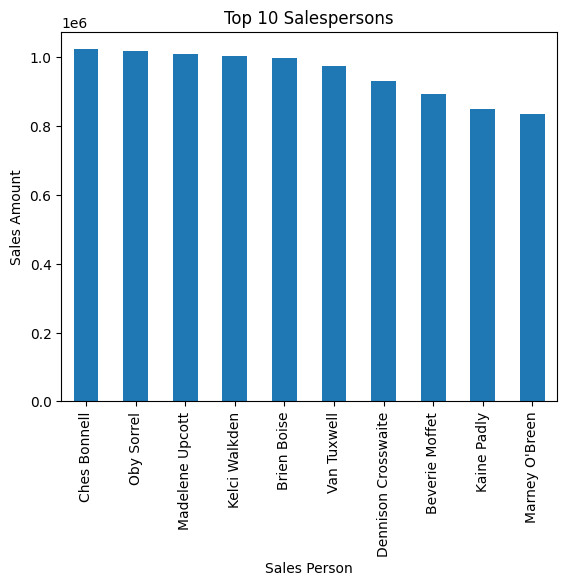

In [18]:
person_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure()
person_sales.plot(kind='bar')
plt.title("Top 10 Salespersons")
plt.xlabel("Sales Person")
plt.ylabel("Sales Amount")
plt.show()

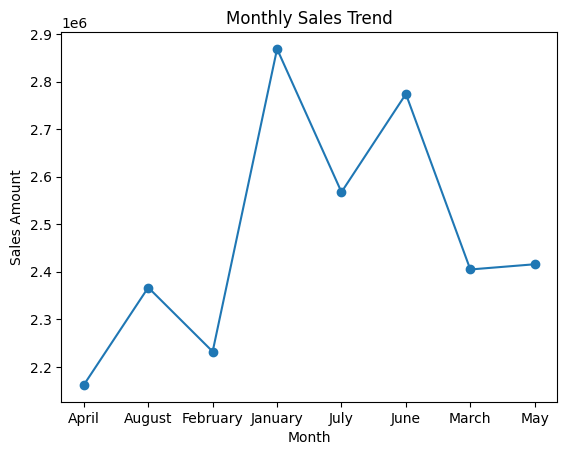

In [19]:
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()

Generate insights

In [20]:
top_country = country_sales.idxmax()
top_product = product_sales.idxmax()
top_person = person_sales.idxmax()
total_sales = df['Amount'].sum()

insights_text = f"""
Chocolate Sales Report Insights

Total Sales: ${total_sales:,.2f}

Top Performing Country: {top_country}
Top Selling Product: {top_product}
Best Sales Person: {top_person}

Total Records: {len(df)}
"""
print(insights_text)



Chocolate Sales Report Insights

Total Sales: $19,791,571.86

Top Performing Country: Australia
Top Selling Product: Smooth Sliky Salty
Best Sales Person: Ches Bonnell

Total Records: 3282



# 4. Save to pdf

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Load dataset
file_path = "D:/SEMESTER 5 pratical/Advanced python programming for data science/data/Chocolate Sales (2).csv"
df = pd.read_csv(file_path)

# Transform Amount
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Date transformation
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Text cleaning
df['Sales Person'] = df['Sales Person'].str.strip()
df['Country'] = df['Country'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()

# Aggregation
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
person_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
monthly_sales = df.groupby('Month')['Amount'].sum()
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
monthly_sales = monthly_sales.reindex(month_order)

# Insights text
top_country = country_sales.idxmax()
top_product = product_sales.idxmax()
top_person = person_sales.idxmax()
total_sales = df['Amount'].sum()

insights_text = f"""
Chocolate Sales Report Insights

Total Sales: ${total_sales:,.2f}
Top Country: {top_country}
Top Product: {top_product}
Best Sales Person: {top_person}
Total Records: {len(df)}
"""

# Save to PDF
pdf_path = "D:/SEMESTER 5 pratical/Advanced python programming for data science/data/Chocolate_Sales_Report.pdf"

with PdfPages(pdf_path) as pdf:

    # Page 1: Insights
    plt.figure()
    plt.text(0.1, 0.5, insights_text, fontsize=12)
    plt.axis('off')
    pdf.savefig()
    plt.close()

    # Page 2: Country sales
    plt.figure()
    country_sales.plot(kind='bar')
    plt.title("Total Sales by Country")
    plt.xlabel("Country")
    plt.ylabel("Sales Amount")
    pdf.savefig()
    plt.close()

    # Pag 3: Product sales
    plt.figure()
    product_sales.plot(kind='bar')
    plt.title("Total Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Sales Amount")
    pdf.savefig()
    plt.close()

    # Page 4: Monthly trend
    plt.figure()
    monthly_sales.plot(kind='line', marker='o')
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales Amount")
    pdf.savefig()
    plt.close()

print("PDF Report Saved at:", pdf_path)


<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
C:\Users\acer\AppData\Local\Temp\ipykernel_17248\88870230.py:10: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)


PDF Report Saved at: D:/SEMESTER 5 pratical/Advanced python programming for data science/data/Chocolate_Sales_Report.pdf


## Q . N to N automated analytic pipeline for netfilx or amazon. Write a case study for it

### Case Study: Automated End-to-End Analytics Pipeline for Netflix

#### 1. Background

Netflix is a leading subscription-based streaming service delivering movies, series, and documentaries globally.  
With millions of users generating massive amounts of data daily (watch history, search queries, ratings, device types), managing and analyzing this data is crucial for **personalized recommendations, churn prediction, and content optimization**.

Manual analytics is inefficient at this scale. Therefore, an **automated end-to-end (N-to-N) analytics pipeline** is essential to transform raw data into actionable insights in real-time.

---

#### 2. Objective

- Automate data ingestion from multiple sources (user activity logs, streaming metrics, content database).  
- Clean, transform, and aggregate data automatically.  
- Generate actionable insights for content recommendation, marketing, and operational optimization.  
- Visualize insights and generate reports for decision-makers without manual intervention.

---

#### 3. Pipeline Architecture

The N-to-N automated analytics pipeline consists of **6 main stages**:

##### A. Data Sources

| Source Type       | Examples                                     |
|-----------------|---------------------------------------------|
| Streaming logs    | Watch start/end times, buffering events    |
| User profiles     | Age, location, subscription tier           |
| Ratings & Reviews | Likes, ratings, comments                    |
| Device & Platform | Mobile, TV, web browser usage              |
| External Data     | Social media trends, release schedules     |

##### B. Data Ingestion (Extract)

- **Batch ingestion:** Daily logs collected from backend servers and stored in cloud storage (e.g., Amazon S3).  
- **Streaming ingestion:** Real-time events ingested via **Kafka** or **AWS Kinesis**.  
- Data stored in a **central data lake** (Amazon S3 or HDFS) for flexibility.

##### C. Data Cleaning & Transformation (Transform)

- **Cleaning:** Handle missing values, duplicates, invalid timestamps.  
- **Transformation:**  
  - Convert raw logs into structured tables (`user_id`, `content_id`, `watch_time`).  
  - Standardize data types (timestamps, numeric ratings).  
  - Derive features such as **average watch time per genre** or **weekly active users**.  
- **Tools:** Apache Spark / Pandas for batch, PySpark Streaming for real-time.

##### D. Data Storage (Load)

- Structured tables stored in **data warehouse** (Amazon Redshift, Snowflake).  
- Optimized for **OLAP queries**, aggregation, and fast retrieval.

##### E. Analytics & Machine Learning

- **Descriptive Analytics:**  
  - Top 10 watched content by region.  
  - Average session duration per user.  

- **Predictive Analytics:**  
  - Churn prediction using logistic regression or XGBoost.  
  - Content recommendation using collaborative filtering or deep learning.  

- **Prescriptive Analytics:**  
  - Suggest which content to promote.  
  - Optimize content licensing and production.

##### F. Visualization & Reporting

- **Automated dashboards:** Power BI, Tableau, or custom web dashboards.  
- **Real-time alerts:** Notify marketing teams of sudden user behavior changes.  
- **Scheduled reports:** Weekly summaries sent via email automatically.

---

#### 4. Automation & Scheduling

- **Orchestration tools:** Apache Airflow / Prefect  
  - Automates daily ETL pipelines.  
  - Handles dependency management (cleaning → aggregation → ML model update).  

- **CI/CD for ML models:**  
  - Models retrained automatically with new data.  
  - Deployment via Docker/Kubernetes for production inference.

---

#### 5. Key Benefits

| Benefit                    | Impact                                                      |
|-----------------------------|------------------------------------------------------------|
| Faster decision-making      | Automated dashboards provide real-time insights            |
| Personalized user experience| Recommendation engine improves engagement and retention    |
| Cost optimization           | Data-driven content licensing and production planning      |
| Scalability                 | Supports millions of users and TBs of streaming data      |
| Reduced manual effort       | Fully automated ETL and reporting reduces human error     |

---

#### 6. Challenges

- Ensuring **data quality** from multiple heterogeneous sources.  
- Handling **high-velocity streaming data** without delay.  
- Updating ML models **without affecting production performance**.  
- Securing **user privacy and GDPR compliance**.

---

#### 7. Tools & Technologies

| Stage                   | Tools / Frameworks                              |
|-------------------------|------------------------------------------------|
| Ingestion               | Kafka, AWS Kinesis, NiFi                        |
| Storage                 | S3, HDFS, Redshift, Snowflake                  |
| ETL/Transformation      | Spark, PySpark, Pandas                          |
| Analytics/ML            | Python, Scikit-learn, TensorFlow, PyTorch      |
| Visualization           | Tableau, Power BI, Matplotlib, Seaborn         |
| Orchestration           | Airflow, Prefect                                |
| Deployment              | Docker, Kubernetes                              |

---

#### 8. Conclusion

An **N-to-N automated analytics pipeline** allows Netflix to convert **raw streaming data into actionable insights efficiently and at scale**.  
It enhances personalization, reduces churn, guides content strategy, and ensures real-time operational visibility.  

This pipeline can be extended to other platforms like **Amazon** for analyzing **purchase behavior, recommendations, and supply chain optimization**.
